# 🏨 Hotel Cancellation Prediction: Logistic Regression Lab
## Can we predict which bookings will be cancelled before they happen?

---

### The Business Problem

Hotel cancellations are a massive headache for the hospitality industry.  
Consider a hotel with 200 rooms that is fully booked for a Saturday night:

- If **20% of bookings cancel** (a realistic figure), the hotel loses revenue on 40 rooms it could have re-sold.
- If the hotel **overbooks aggressively** and fewer people cancel than expected, it must walk guests to a competitor — destroying customer loyalty.
- You are a data scientist at a fast growing hotel brand and they need a better way to predict cancellations, they have a pretty good size
dataset and would like you to help. If the model works well you get a 10% bonus of all the recovered revenue!  

**A good cancellation-prediction model lets hotels:**
1. **Optimize overbooking** — sell the right number of extra rooms so the hotel fills up even after cancellations.
2.  **Improve staffing** — if 30% of tonight's bookings will cancel, fewer housekeepers and front-desk staff are needed.
3.  **Target at-risk bookings** — reach out proactively with incentives (free breakfast, discount upgrade) to guests who are likely to cancel.

### The Dataset

We are working with the **Hotel Booking Demand** dataset (~119 k real bookings from two Portuguese hotels).  
Our **target variable** is `is_canceled`: `1` if the booking was cancelled, `0` if the guest actually showed up.

### What You Will Build

| Model | Key idea |
|-------|----------|
| **Model 1** | Baseline pipeline — default solver (`lbfgs`), one-hot encoding + standard scaling |
| **Model 2** | Solver exploration — try using different solvers and see if the model improves |
| **Model 3** | Class-weighted logistic regression + cross-validation to handle imbalanced labels |



---
## 1 · Setup & Data Loading

In [1]:
# Import all necessary libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression

from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
# OneHotEncoder: convert categorical variables into numeric (0/1) columns
# StandardScaler: standardize numeric features to mean = 0, std = 1
# MinMaxScaler: scale numeric features to a fixed range (usually 0-1)

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve,
    classification_report
)
# confusion matrix: evaluate classification performance by showing true vs predicted labels
# roc_auc_score: evalatuate probabilistic predictions (compute area under the ROC curve - performance metric for binary classifiers)
# classification report: summarize precision, recall, f1-score for each class

sns.set_style('whitegrid')

In [2]:
# Read in the data
df = pd.read_csv('hotels.csv')


---
## 2 · Exploratory Data Analysis

Before building any model we need to **understand our data**.  


In [ ]:
# Print out summary stats and basic info on the dataset, what trends do you notice?
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [3]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [4]:
# Look at target variable distribution
df['is_canceled'].value_counts()


is_canceled
0    75166
1    44224
Name: count, dtype: int64

In [ ]:
# normalized distribution of target variables - returns proportions of each unique value rather than counts
df['is_canceled'].value_counts(normalize=True)

# Trends: There are more non-cancelled bookings than cancelled bookings, 
# which means the distribution is moderately imbalanced.

is_canceled
0    0.629584
1    0.370416
Name: proportion, dtype: float64

In [ ]:
# Trends: There are a lot of categorical and numerical features in this dataset, 
# which means we will need to do some preprocessing before we can train a model.

In [ ]:
# Calculate prevalence of the target value, how hard of problem is this going to be?

# Store the number of cancelled (1) and non-cancelled bookings (0) in a variable 
counts = df['is_canceled'].value_counts()

# Prevalence of cancelled bookings (proportion of cancelled bookings out of total bookings)
prevalence = counts[1] / counts.sum()

print(f'Prevalence of cancelled bookings: {prevalence:.2%}')

Prevalence of cancelled bookings: 37.04%


In [ ]:
# The prevalence of cancelled bookings is 37.04%. 
# 37.04% of the bookings were cancelled.
# This also indicates that the dataset is moderately imbalanced in the classes, but not extremely so we can preceed with logistic regression. 
# It still may affect the model performance (so we should account for it to avoid bias towards not cancelled group).

---
## 3 · Feature Engineering - Preparation

Before building any model we need to **understand our data**. 

In [8]:
# Check for missing data and drop features with too many missing values, there are some. 
df.isnull().sum().sort_values(ascending=False)
# The 'company' and 'agent' features have a large proportion of missing values, 
# so we will drop them from the dataset.

company                           112593
agent                              16340
country                              488
children                               4
arrival_date_month                     0
arrival_date_week_number               0
hotel                                  0
is_canceled                            0
stays_in_weekend_nights                0
arrival_date_day_of_month              0
adults                                 0
stays_in_week_nights                   0
babies                                 0
meal                                   0
lead_time                              0
arrival_date_year                      0
distribution_channel                   0
market_segment                         0
previous_bookings_not_canceled         0
is_repeated_guest                      0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
previous_cancellations                 0
deposit_type    

In [9]:
# Drop the 'company' and 'agent' features 
df = df.drop(columns=['company', 'agent'])

# Drop the NA values in the children and country features because 
# there are not that many and we don't want to remove the variable entirely.
df = df.dropna(subset = ['children', 'country'])


In [10]:
# There are two other features that need to be dropped because they  directly leak the target variable.
# Another way to say this is they represent leakage in the dataset.

df_cleaned = df.drop(columns=['reservation_status', 'reservation_status_date', 'is_canceled'])
# We dropped the 'reservation_status' and 'reservation_status_date' features because they tell you whether or not the reservation was cancelled and when.
# We also dropped the 'is_canceled' feature because that is our target variable.


---
### Feature groups, see step 4 in the example (i think it goes 1,2,4 I deleted 3 and didn't change the numbering)

Create lists for the **numerical** and **categorical** so we can apply the right transformations to each group inside a `ColumnTransformer`.

> **Why scale numerics?** Logistic regression uses gradient descent internally.  
> Features on very different scales (e.g. `lead_time` 0–737 vs `adults` 0–4) slow convergence.  
> `StandardScaler` fixes this by converting each feature to mean=0, std=1.

> **Why one-hot encode categoricals?** Logistic regression can't handle strings.  
> One-hot encoding converts each category into its own binary (0/1) column.

Keep in mind that we want to use the pipeline package to handle this preprocessing so create lists of names of numeric and category then pass them into the pipeline, not necessarily creating different dataframes. 



In [11]:
# Use to look at all the columns in the cleaned dataset to make sure 
# we dropped the right ones and to see what features we have to work with.
df_cleaned.columns

Index(['hotel', 'lead_time', 'arrival_date_year', 'arrival_date_month',
       'arrival_date_week_number', 'arrival_date_day_of_month',
       'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children',
       'babies', 'meal', 'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type',
       'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests'],
      dtype='str')

In [12]:
df_cleaned.info()

<class 'pandas.DataFrame'>
Index: 118898 entries, 0 to 119389
Data columns (total 27 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           118898 non-null  str    
 1   lead_time                       118898 non-null  int64  
 2   arrival_date_year               118898 non-null  int64  
 3   arrival_date_month              118898 non-null  str    
 4   arrival_date_week_number        118898 non-null  int64  
 5   arrival_date_day_of_month       118898 non-null  int64  
 6   stays_in_weekend_nights         118898 non-null  int64  
 7   stays_in_week_nights            118898 non-null  int64  
 8   adults                          118898 non-null  int64  
 9   children                        118898 non-null  float64
 10  babies                          118898 non-null  int64  
 11  meal                            118898 non-null  str    
 12  country                         

In [14]:
# Prepare for the pipeline make sure to do so for both **numerical** and **categorical**. 
# Generate dataframe for the features and target variable, X and y.

# Define all categorical variables
cat_features = ['hotel', 'arrival_date_year', 'arrival_date_month', 'meal', 'country', 'market_segment', 
                'distribution_channel', 'is_repeated_guest', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']

# Define all numerical variables
num_features = ['lead_time', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 
                'stays_in_week_nights', 'adults', 'children', 'babies', 'previous_cancellations', 'previous_bookings_not_canceled', 
                'booking_changes', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']

# Define the target variable
target = 'is_canceled'

# Predictors
X = df_cleaned[cat_features + num_features]

# Target variable
y = df[target]

In [15]:
# Train / test split — 80/20, stratified so class ratios are preserved

# 80% of the data for training, 20% for testing, random state = 42 for 
# reproducibility, stratify by y to maintain proportions of cancelled vs 
# non-cancelled bookings in both sets.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
# Number of rows in train and test sets (should be 80/20 split)
print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")

# Percentage of positive class (cancelled bookings) in train set
percent_positive_train = y_train.mean() * 100
print(f"Train positive class: {percent_positive_train:.2f}%")

# Percentage of positive class (cancelled bookings) in test set
percent_positive_test = y_test.mean() * 100
print(f"Test positive class: {percent_positive_test:.2f}%")

# Roughly 37% of the bookings were cancelled in both the train and test sets, 
# which is consistent with the overall prevalence in the dataset.

Train: 95118 rows | Test: 23780 rows
Train positive class: 37.13%
Test positive class: 37.14%


---
## 4 · Model Building and Evaluation

Now we are going to build our **model pipeline** and use the transformers

---
Model 1 — Baseline Logistic Regression

Our first pipeline is intentionally **simple**.  
The goal is to establish a baseline score we can try to beat later.
Transformer categorical using one-hot encoding and numerical using the MinMaxscaler()

X_raw  →  ColumnTransformer  →  LogisticRegression(solver='lbfgs')
           (scale + encode)


**`lbfgs`** (Limited-memory Broyden–Fletcher–Goldfarb–Shanno) is sklearn's default solver, like we talked about in class

---
Model 1 Evaluation: Now that the model is built lets evaluate the model using confusion matrix and ROC/AUC. Give the goal of your assignment how well does the model work?

The Confusion Matrix Will Be Important Evaluation Tool

For a hotel-cancellation problem the four cells of the confusion matrix have real business meaning:

\ | Predicted: Kept | Predicted: Cancelled |
|---|---|---|
| **Actual: Kept** |  **True Negative (TN)** — correctly identified loyal guest |  **False Positive (FP)** — wrongly flagged a loyal guest as a canceller |
| **Actual: Cancelled** |  **False Negative (FN)** — missed a cancellation (costly!) |  **True Positive (TP)** — correctly predicted a cancellation |

**Business impact:**
- **False Negatives** are expensive — we didn't anticipate the cancellation, so we can't fill the room.
- **False Positives** are annoying but cheaper — we might over-staff or over-book slightly.


In [16]:
# Set up a pipeline to preprocess the data and train a logistic regression model

# ColumnTransformer: apply different preprocessing steps to the categorical and numerical features
# OneHotEncoder: convert categorical variables into numeric (0/1) columns
# MinMaxScaler: scale numeric features to a fixed range (usually 0-1)

preprocessor_m1 = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features), 
    ('num', MinMaxScaler(), num_features) 
])

# 'prep' applies the preprocessing steps defined in preprocessor_m1
# 'model' trains a logistic regression model on the preprocessed data
pipe_m1 = Pipeline(steps=[
    ('prep',  preprocessor_m1),
    ('model', LogisticRegression(max_iter=5000, random_state=42, n_jobs=-1))
])
# max_iter = 5000 to ensure convergence (b/c there are a lot of features after one hot econding), 
# random_state = 42 for reproducibility, 
# n_jobs = -1 to use all CPU cores (speeds up computation)

# Fit the pipeline on the training data
pipe_m1.fit(X_train, y_train)

/workspaces/Logistic_Regression_Lab/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

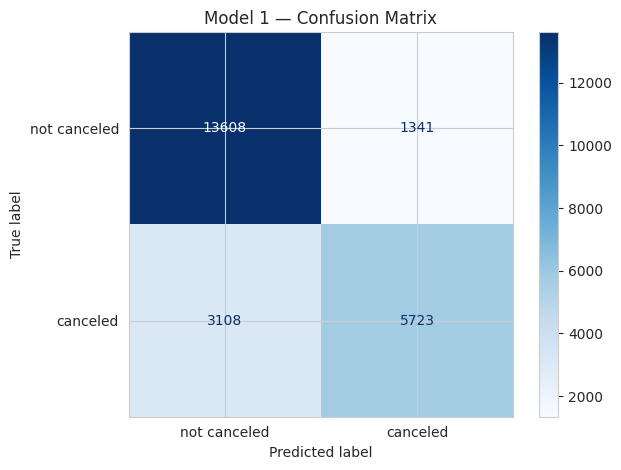

              precision    recall  f1-score   support

not canceled       0.81      0.91      0.86     14949
    canceled       0.81      0.65      0.72      8831

    accuracy                           0.81     23780
   macro avg       0.81      0.78      0.79     23780
weighted avg       0.81      0.81      0.81     23780



In [ ]:
# Use trained pipeline to predict whether each booking the test set was cancelled or not
y_pred_m1 = pipe_m1.predict(X_test)

# Evaluate the model performance using a confusion matrix and classification report

# Compute confusion matrix for Model 1
cm_m1 = confusion_matrix(y_test, y_pred_m1)

# Create display object for confusion matrix with labels for classes 
disp_m1 = ConfusionMatrixDisplay(confusion_matrix=cm_m1, display_labels=['not canceled', 'canceled'])

# Plot confusion matrix
disp_m1.plot(cmap='Blues')
plt.title('Model 1 — Confusion Matrix')
plt.tight_layout()
plt.show()

# Provides metrics for each class
print(classification_report(y_test, y_pred_m1, target_names=['not canceled', 'canceled']))

In [17]:
# Classification Metrics
# Precision: Of all the bookings the model predicted as cancelled, how many were actually cancelled?
# 81% of the bookings that the model predicted as cancelled were actually cancelled.
# 81% of the bookings predicted as "not canceled" were  correctly identified. 

# Recall: Of all the bookings that were actually cancelled, how many did the model correctly identify as cancelled?
# 65% of the cancelled bookings were correctly identified by the model.
# 91% of the non-cancelled bookings were correctly identified by the model.

# F-1 score: Harmonic mean of precision and recall (single metric that balances both precision and recall)
# F-1 score for cancelled class is 0.72, which indicates a good balance between precision and recall for the cancelled bookings.
# F-1 score for non-cancelled class is 0.86, which indicates a good balance between precision and recall for the non-cancelled bookings.

# Support: Number of actual instances in that class 
# 8831 cancelled bookings and 14949 non-cancelled bookings in the test set.

# Accuracy: overall, 81% of all bookings were correctly classified. 
# macro avg: weighted all classes equally
# weighted avg: accounts for class imbalance by weighting the average according to the number of instances in each class

---
 Model 1 Evaluation: Now that the model is build lets evaluate the model using confusion matrix and ROC/AUC. Give the goal of your assignment how well does the model work?

The Confusion Matrix Will Be Important Evaluation Tool

For a hotel-cancellation problem the four cells of the confusion matrix have real business meaning:

| | Predicted: Kept | Predicted: Cancelled |
|---|---|---|
| **Actual: Kept** |  **True Negative (TN)** — correctly identified loyal guest |  **False Positive (FP)** — wrongly flagged a loyal guest as a canceller |
| **Actual: Cancelled** |  **False Negative (FN)** — missed a cancellation (costly!) |  **True Positive (TP)** — correctly predicted a cancellation |

**Business impact:**
- **False Negatives** are expensive — we didn't anticipate the cancellation, so we can't fill the room.
- **False Positives** are annoying but cheaper — we might over-staff or over-book slightly.

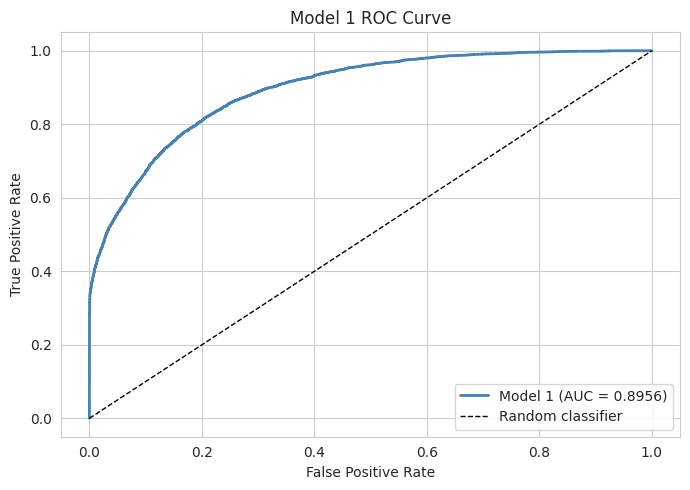

Model 1 ROC-AUC: 0.8956


In [18]:
# Predict probabilities for positive class (cancelled bookings) 
y_proba_m1 = pipe_m1.predict_proba(X_test)[:, 1]

# Compute ROC curve with false positive rate (fpr), true positive rate (tpr), and thresholds
fpr_m1, tpr_m1, thresholds = roc_curve(y_test, y_proba_m1)

# Compute area under the curve (AUC) for Model 1
auc_m1 = roc_auc_score(y_test, y_proba_m1)

# Plot ROC curve for Model 1
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_m1, tpr_m1, lw=2, color='steelblue', label=f'Model 1 (AUC = {auc_m1:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Model 1 ROC Curve')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"Model 1 ROC-AUC: {auc_m1:.4f}")

In [19]:
# A ROC-AUC of 0.8956 means that the model has decent discriminatory ability 
# between cancelled and non-cancelled bookings, and is performing much better 
# than random guessing.

# The model can correctly distinguish between cancelled and non-cancelled bookings 
# higher than a randomly chosen booking about 89.56% of the time.

---
## 5 · Model 2 — Exploring Different Solvers 

- Adjust your model object in the pipeline then evaluate again using confusion matrix and ROC/AUC. Make sure to eval on the test set. You should create a model_2_pipe, use much of the same code but create a new pipeline for each model

Sklearn's `LogisticRegression` supports several **solvers** (optimisation algorithms) and  
**regularisation strategies** controlled by `l1_ratio` and `C`.

| Solver | Best for |
|--------|----------|
| `lbfgs` | Default; works well on most datasets (L2 regularisation) |
| `liblinear` | Smaller datasets; supports L1 via `l1_ratio=1` |
| `saga` | Large datasets; supports L1, L2, and ElasticNet |


Did the model improve based on the various solvers?



In [20]:
# Preprocessing for Model 2
preprocessor_m2 = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features),
    ('num', MinMaxScaler(), num_features)
])

# Model 2 using the default 'lbfgs' solver
pipe_m2_lbfgs = Pipeline(steps=[
    ('prep',  preprocessor_m2),
    ('model', LogisticRegression(max_iter=5000, random_state=42, n_jobs=-1))
])

pipe_m2_lbfgs.fit(X_train, y_train)
print("Model 2 lbfgs fitted.")

# Model 2 using the 'liblinear' solver
pipe_m2_liblinear = Pipeline(steps=[
    ('prep',  preprocessor_m2),
    ('model', LogisticRegression(solver = 'liblinear', max_iter=5000, random_state=42, n_jobs=-1))
])

pipe_m2_liblinear.fit(X_train, y_train)
print("Model 2 liblinear fitted.")

# Model 2 using the 'saga' solver
pipe_m2_saga = Pipeline(steps=[
    ('prep',  preprocessor_m2),
    ('model', LogisticRegression(solver = 'saga', max_iter=5000, random_state=42, n_jobs=-1))
])

pipe_m2_saga.fit(X_train, y_train)
print("Model 2 saga fitted.")

/workspaces/Logistic_Regression_Lab/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Model 2 lbfgs fitted.


/workspaces/Logistic_Regression_Lab/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Model 2 liblinear fitted.


/workspaces/Logistic_Regression_Lab/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Model 2 saga fitted.


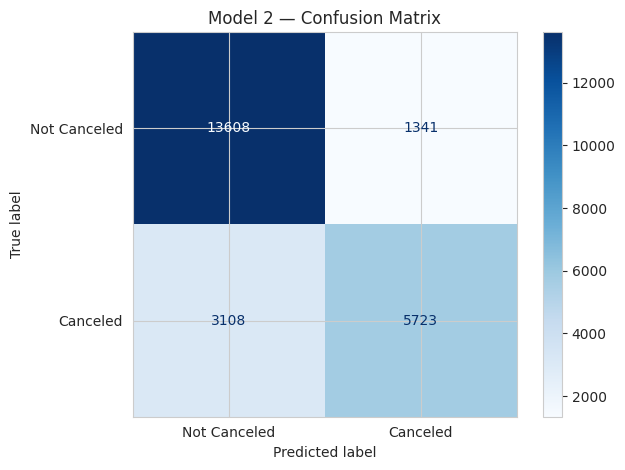

              precision    recall  f1-score   support

Not Canceled       0.81      0.91      0.86     14949
    Canceled       0.81      0.65      0.72      8831

    accuracy                           0.81     23780
   macro avg       0.81      0.78      0.79     23780
weighted avg       0.81      0.81      0.81     23780



In [21]:
# Evaluate Model 2 with 'lbfgs' solver
y_pred_m2_lbfgs = pipe_m2_lbfgs.predict(X_test)
cm_m2_lbfgs = confusion_matrix(y_test, y_pred_m2_lbfgs)
disp_m2_lbfgs = ConfusionMatrixDisplay(confusion_matrix=cm_m2_lbfgs, display_labels=['Not Canceled', 'Canceled'])
disp_m2_lbfgs.plot(cmap='Blues')
plt.title('Model 2 — Confusion Matrix')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_m2_lbfgs, target_names=['Not Canceled', 'Canceled']))

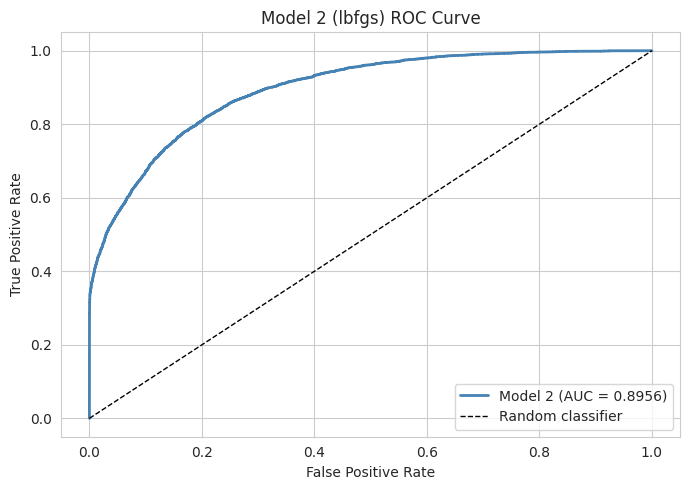

Model 2 (lbfgs) ROC-AUC: 0.8956


In [22]:
# ROC curve for Model 2 with 'lbfgs' solver
y_proba_m2_lbfgs = pipe_m2_lbfgs.predict_proba(X_test)[:, 1]
fpr_m2, tpr_m2, thresholds_m2 = roc_curve(y_test, y_proba_m2_lbfgs)
auc_m2 = roc_auc_score(y_test, y_proba_m2_lbfgs)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_m2, tpr_m2, lw=2, color='steelblue', label=f'Model 2 (AUC = {auc_m2:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Model 2 (lbfgs) ROC Curve')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"Model 2 (lbfgs) ROC-AUC: {auc_m2:.4f}")

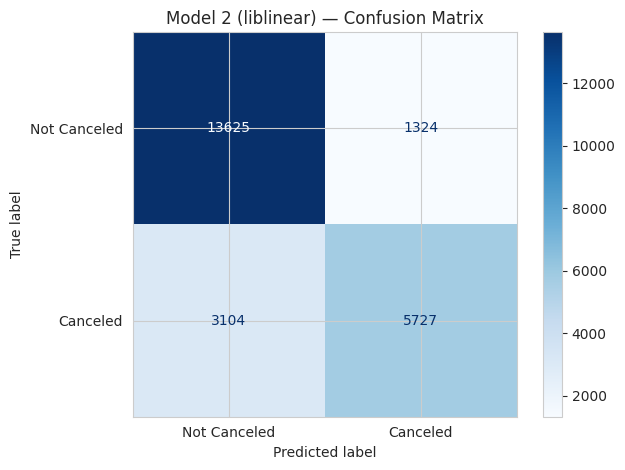

              precision    recall  f1-score   support

Not Canceled       0.81      0.91      0.86     14949
    Canceled       0.81      0.65      0.72      8831

    accuracy                           0.81     23780
   macro avg       0.81      0.78      0.79     23780
weighted avg       0.81      0.81      0.81     23780



In [23]:
# Evaluate Model 2 with 'liblinear' solver
y_pred_m2_liblinear = pipe_m2_liblinear.predict(X_test)
cm_m2_liblinear = confusion_matrix(y_test, y_pred_m2_liblinear)
disp_m2_liblinear = ConfusionMatrixDisplay(confusion_matrix=cm_m2_liblinear, display_labels=['Not Canceled', 'Canceled'])
disp_m2_liblinear.plot(cmap='Blues')
plt.title('Model 2 (liblinear) — Confusion Matrix')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_m2_liblinear, target_names=['Not Canceled', 'Canceled']))


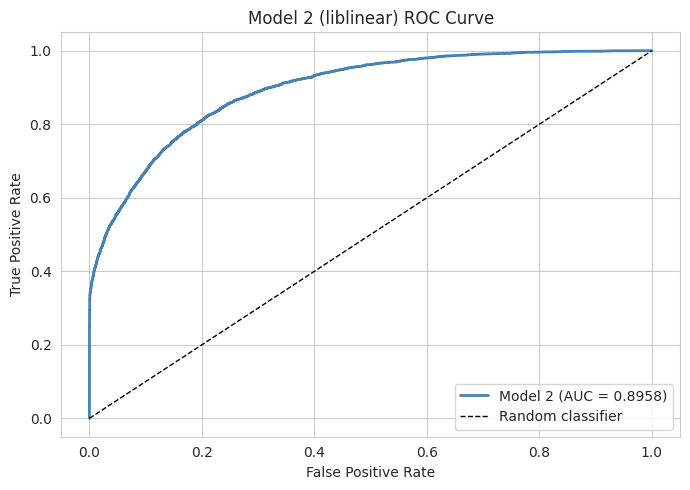

Model 2 (liblinear) ROC-AUC: 0.8958


In [24]:
# ROC curve for Model 2 with 'liblinear' solver
y_proba_m2_liblinear = pipe_m2_liblinear.predict_proba(X_test)[:, 1]
fpr_m2, tpr_m2, thresholds_m2 = roc_curve(y_test, y_proba_m2_liblinear)
auc_m2 = roc_auc_score(y_test, y_proba_m2_liblinear)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_m2, tpr_m2, lw=2, color='steelblue', label=f'Model 2 (AUC = {auc_m2:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Model 2 (liblinear) ROC Curve')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"Model 2 (liblinear) ROC-AUC: {auc_m2:.4f}")

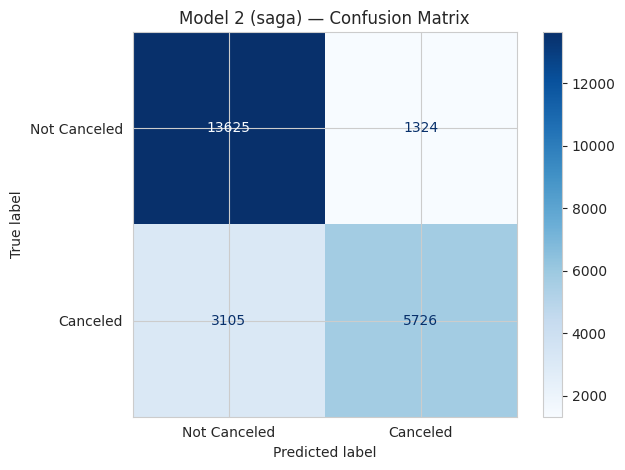

              precision    recall  f1-score   support

Not Canceled       0.81      0.91      0.86     14949
    Canceled       0.81      0.65      0.72      8831

    accuracy                           0.81     23780
   macro avg       0.81      0.78      0.79     23780
weighted avg       0.81      0.81      0.81     23780



In [26]:
# Evaluate Model 2 with 'saga' solver
y_pred_m2_saga = pipe_m2_saga.predict(X_test)
cm_m2_saga = confusion_matrix(y_test, y_pred_m2_saga)
disp_m2_saga = ConfusionMatrixDisplay(confusion_matrix=cm_m2_saga, display_labels=['Not Canceled', 'Canceled'])
disp_m2_saga.plot(cmap='Blues')
plt.title('Model 2 (saga) — Confusion Matrix')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_m2_saga, target_names=['Not Canceled', 'Canceled']))

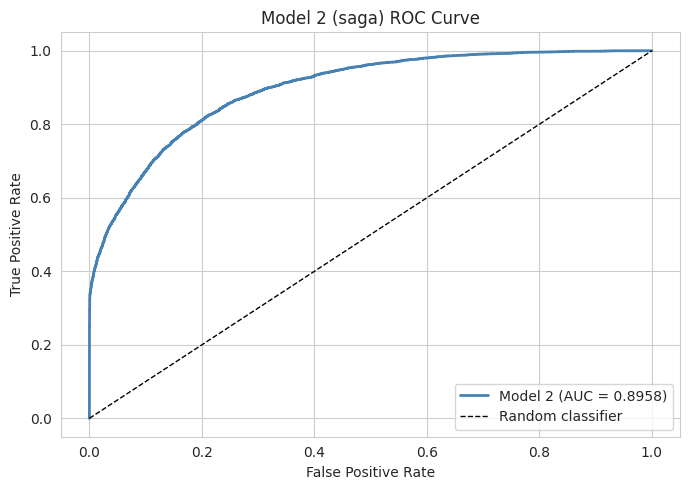

Model 2 (saga) ROC-AUC: 0.8958


In [27]:
# ROC curve for Model 2 with 'saga' solver
y_proba_m2_saga = pipe_m2_saga.predict_proba(X_test)[:, 1]
fpr_m2, tpr_m2, thresholds_m2 = roc_curve(y_test, y_proba_m2_saga)
auc_m2 = roc_auc_score(y_test, y_proba_m2_saga)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_m2, tpr_m2, lw=2, color='steelblue', label=f'Model 2 (AUC = {auc_m2:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Model 2 (saga) ROC Curve')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"Model 2 (saga) ROC-AUC: {auc_m2:.4f}")

In [28]:
# All three solvers (lbfgs, liblinear, saga) produced the similar/same classification
# report and ROC-AUC score, which suggests that the choice of solver did not 
# have a significant impact on the model's performance. 

# Accuracy and F-1 scores are identical across all thre solvers, and the ROC-AUC values 
# are also very similar (all around 0.895), which indicates that all three solvers converged 
# to a similar solution and produced similar performance on the test set.

# Therefore, changing the solver did not improve the predictive performance of this model.
# Any of the three solvers works equally well for this dataset. 

# This is because logistic regression solves the same optimization problem regardless of the solver. 

---
## 6 · Model 3 — Balanced Class Weights + Cross-Validation

Build a final model (pipe_3) with a balanced class weight and use cross validation. As a reminder cv happens on the fit process not as part of the pipeline and we need to build our CV object, similar to the model object. . 

Use the example shown in class to see how to apply cross validation, balanced weight is a argument in the logreg function that you just need to apply as seen below. 

### The Class Imbalance Problem

Our dataset has ~63% non-cancellations and ~37% cancellations.  
A lazy model could achieve 63% accuracy by *always* predicting "Kept"!  
We saw that Models 1 and 2 sometimes struggled with **recall on the cancelled class**.

### Solution: `class_weight='balanced'`

Setting `class_weight='balanced'` tells sklearn to automatically weight the training samples  
so that the minority class (cancellations) gets more attention during training.

Specifically, each class gets weight = `n_samples / (n_classes × n_samples_in_class)`.

### Solution: Cross-Validation

Instead of a single train/test split (which can be lucky or unlucky),  
**k-fold cross-validation** trains and evaluates the model on `k` different splits  
and reports the average — giving a much more reliable estimate of real-world performance.

```
Fold 1: [train | train | train | train | VAL ]
Fold 2: [train | train | train | VAL  | train]
Fold 3: [train | train | VAL  | train | train]
...and so on
```

---

### Experiments

- Change the number of folds from `5` to `10` — does the mean AUC change much?
- Try removing `class_weight='balanced'` — what happens to recall on the cancelled class?

In [29]:
# # Preprocessing for Model 3
preprocessor_m3 = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features),
    ('num', MinMaxScaler(), num_features)
])

# Add class_weight = 'balanced' to account for class imbalance in the dataset
pipe_m3 = Pipeline(steps=[
    ('prep',  preprocessor_m3),
    ('model', LogisticRegression(max_iter=5000, random_state=42, n_jobs = -1, class_weight='balanced'))
])

In [30]:
# Splits dataset into 5 folds for cross-validation, 
# shuffle the data before splitting, 
# random state = 42 for reproducibility
# (stratified means each fold preserves proportions of the target classes)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Computes ROC-AUC and F1 scores for each fold of the cross-validation
cv_auc  = cross_val_score(pipe_m3, X, y, cv=cv, scoring='roc_auc')
cv_f1   = cross_val_score(pipe_m3, X, y, cv=cv, scoring='f1')

print("5-Fold Cross-Validation Results (Logistic Regression with balanced class weights):")
# mean and standard deviation (variability) of the ROC-AUC and F1 scores across the 5 folds
print(f"  ROC-AUC : {cv_auc.mean():.4f}  ± {cv_auc.std():.4f}  | folds: {np.round(cv_auc, 4)}")
print(f"  F1      : {cv_f1.mean():.4f}  ± {cv_f1.std():.4f}  | folds: {np.round(cv_f1, 4)}")

/workspaces/Logistic_Regression_Lab/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/workspaces/Logistic_Regression_Lab/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/workspaces/Logistic_Regression_Lab/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/workspaces/Logistic_Regression_Lab/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' h

5-Fold Cross-Validation Results (Logistic Regression with balanced class weights):
  ROC-AUC : 0.8936  ± 0.0015  | folds: [0.8924 0.8934 0.8924 0.8933 0.8965]
  F1      : 0.7504  ± 0.0029  | folds: [0.7465 0.7485 0.7524 0.7498 0.7548]


/tmp/ipykernel_77600/3677859772.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([cv_auc], labels=['AUC'], patch_artist=True,


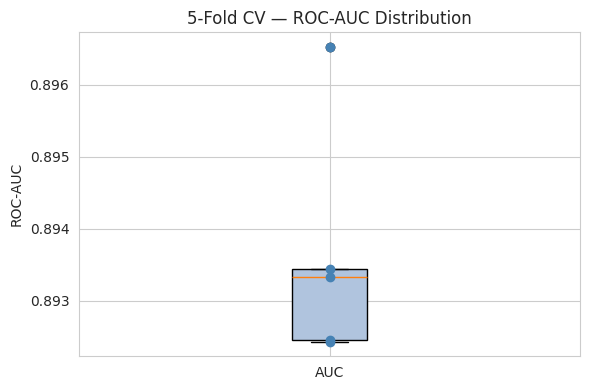

In [ ]:
# Box-plot of 5 fold AUCs
fig, ax = plt.subplots(figsize=(6, 4))
ax.boxplot([cv_auc], labels=['AUC'], patch_artist=True,
           boxprops=dict(facecolor='lightsteelblue'))
ax.scatter([1]*5, cv_auc, color='steelblue', zorder=3)
ax.set_title('5-Fold CV — ROC-AUC Distribution')
ax.set_ylabel('ROC-AUC')
plt.tight_layout()
plt.show()

In [32]:
# 10 folds
cv_10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

cv_auc_10  = cross_val_score(pipe_m3, X, y, cv=cv_10, scoring='roc_auc')
cv_f1_10   = cross_val_score(pipe_m3, X, y, cv=cv_10, scoring='f1')

print("10-Fold Cross-Validation Results (Logistic Regression with balanced class weights):")
print(f"  ROC-AUC : {cv_auc_10.mean():.4f}  ± {cv_auc_10.std():.4f}  | folds: {np.round(cv_auc_10, 4)}")
print(f"  F1      : {cv_f1_10.mean():.4f}  ± {cv_f1_10.std():.4f}  | folds: {np.round(cv_f1_10, 4)}")

/workspaces/Logistic_Regression_Lab/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/workspaces/Logistic_Regression_Lab/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/workspaces/Logistic_Regression_Lab/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/workspaces/Logistic_Regression_Lab/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' h

10-Fold Cross-Validation Results (Logistic Regression with balanced class weights):
  ROC-AUC : 0.8938  ± 0.0025  | folds: [0.8953 0.8903 0.8946 0.8921 0.8903 0.895  0.8922 0.8953 0.8941 0.8988]
  F1      : 0.7507  ± 0.0021  | folds: [0.7492 0.7483 0.7506 0.7471 0.7509 0.7521 0.7516 0.7502 0.7515 0.755 ]


/tmp/ipykernel_77600/838088502.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([cv_auc_10], labels=['AUC'], patch_artist=True,


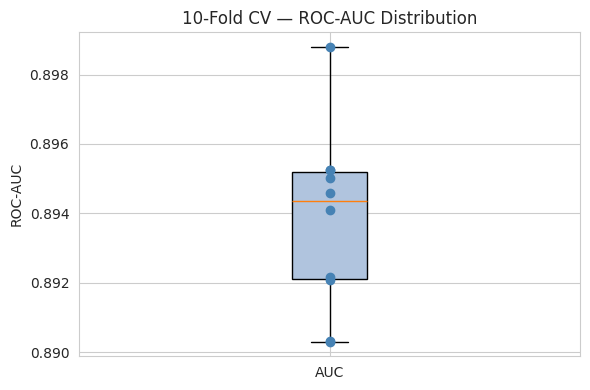

In [35]:
# Box-plot of 10 fold AUCs
fig, ax = plt.subplots(figsize=(6, 4))
ax.boxplot([cv_auc_10], labels=['AUC'], patch_artist=True,
           boxprops=dict(facecolor='lightsteelblue'))
ax.scatter([1]*10, cv_auc_10, color='steelblue', zorder=3)
ax.set_title('10-Fold CV — ROC-AUC Distribution')
ax.set_ylabel('ROC-AUC')
plt.tight_layout()
plt.show()

In [36]:
# 5 Folds vs 10 Folds: Does the ROC-AUC score change?
# Mean ROC-AUC for 5 folds: 0.8936 ± 0.0015
# Mean ROC-AUC for 10 folds: 0.8938 ± 0.0025

# The mean ROC-AUC score is very similar between 5 folds and 10 folds, 
# and the standard deviation is also small and similar, 
# This suggests that increasing the number of folds from 5 to 10 did not 
# significantly change the ROC-AUC score, and therefore did not significantly 
# affect the model's performance.

/workspaces/Logistic_Regression_Lab/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


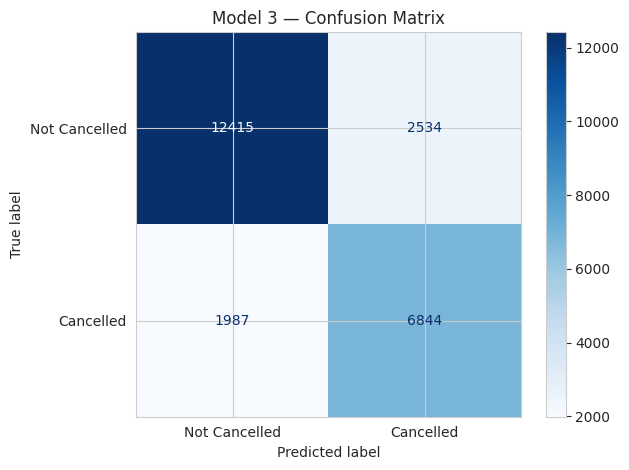

               precision    recall  f1-score   support

Not Cancelled       0.86      0.83      0.85     14949
    Cancelled       0.73      0.77      0.75      8831

     accuracy                           0.81     23780
    macro avg       0.80      0.80      0.80     23780
 weighted avg       0.81      0.81      0.81     23780



In [37]:
# Fit the model on the training data and evaluate on the test set
pipe_m3.fit(X_train, y_train)
y_pred_m3 = pipe_m3.predict(X_test)

# Confusion matrix and classification report for Model 3
cm_m3 = confusion_matrix(y_test, y_pred_m3)
disp_m3 = ConfusionMatrixDisplay(confusion_matrix=cm_m3, display_labels=['Not Cancelled', 'Cancelled'])
disp_m3.plot(cmap='Blues')
plt.title('Model 3 — Confusion Matrix')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_m3, target_names=['Not Cancelled', 'Cancelled']))

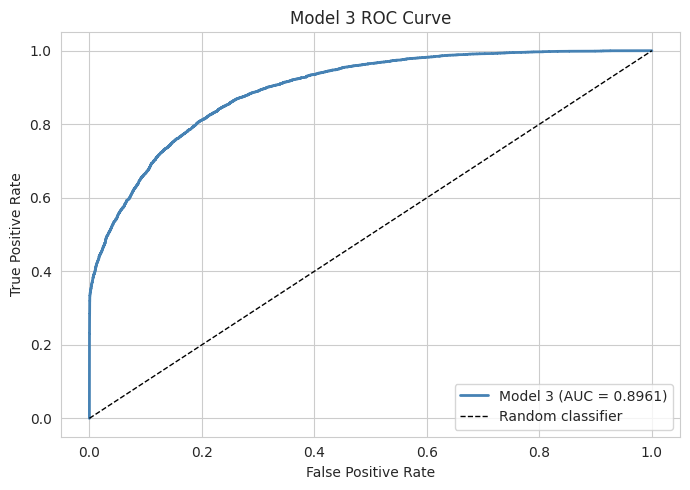

Model 3 ROC-AUC: 0.8961


In [38]:
# ROC-AUC curve for Model 3
y_proba_m3 = pipe_m3.predict_proba(X_test)[:, 1]
fpr_m3, tpr_m3, thresholds_m3 = roc_curve(y_test, y_proba_m3)
auc_m3 = roc_auc_score(y_test, y_proba_m3)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_m3, tpr_m3, lw=2, color='steelblue', label=f'Model 3 (AUC = {auc_m3:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Model 3 ROC Curve')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"Model 3 ROC-AUC: {auc_m3:.4f}")

/workspaces/Logistic_Regression_Lab/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


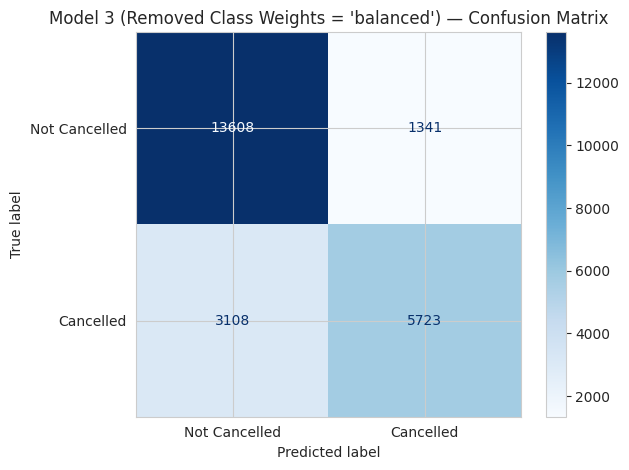

               precision    recall  f1-score   support

Not Cancelled       0.81      0.91      0.86     14949
    Cancelled       0.81      0.65      0.72      8831

     accuracy                           0.81     23780
    macro avg       0.81      0.78      0.79     23780
 weighted avg       0.81      0.81      0.81     23780



In [39]:
# Pipeline for Model 3 without class weights to compare performance
pipe_m3_removed = Pipeline(steps=[
    ('prep',  preprocessor_m3),
    ('model', LogisticRegression(max_iter=5000, random_state=42, n_jobs = -1))
])
pipe_m3_removed.fit(X_train, y_train)

y_pred_m3_removed = pipe_m3_removed.predict(X_test)

# Confusion matrix and classification report for Model 3 without class weights
cm_m3 = confusion_matrix(y_test, y_pred_m3_removed)
disp_m3 = ConfusionMatrixDisplay(confusion_matrix=cm_m3, display_labels=['Not Cancelled', 'Cancelled'])
disp_m3.plot(cmap='Blues')
plt.title("Model 3 (Removed Class Weights = 'balanced') — Confusion Matrix")
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_m3_removed, target_names=['Not Cancelled', 'Cancelled']))

In [40]:
# By considering the class weights, we improved the recall of predicting a cancelled booking from 0.65 to 0.77,
# meaning the model is better at correctly identifying cancelled bookings. 

# The trade off is a slight decrease in recall for the non-cancelled class (from 0.91 to 0.83), 
# but overall accuracy remains the same. 

# Using class weights to account for class imbalance can help improve the model's ability to correctly identify cancelled bookings,
# giving the hotel a better chance at predicting cancellations and plan for them.

---
## 07 · Summary & Reflection

### What We Learned

**Model Performance**
- Which model worked best and why do you think that is the case? Write a short recommendation to your boss on how to proceed (1 paragraph)

### Challenge Extensions - extra 5 points for each

If you want to push further:

1. **Tune `C`** using `GridSearchCV` over the range `[0.001, 0.01, 0.1, 1, 10, 100]`.
2. **Engineer new features** — e.g. `total_nights = stays_in_weekend_nights + stays_in_week_nights`.
3. **Try a different model** — replace `LogisticRegression` in the pipeline with `RandomForestClassifier` or `GradientBoostingClassifier`. Does AUC improve? or maybe kNN
4. **Interpret coefficients** — given that the variables have been standardized create a horizontal bar chart showing
the rankings of the coeficients 

---

In [41]:
# Model 3 performs the best for our business goal. 
# While Model 1 and Model 2 achieved similar overall accuracy, they struggled to identify cancellations, 
# with recall for cancelled bookings being only 0.65. 
# This means that the hotel could fail to predict many guests who may cancel. 
# Unlike Model 1 and 2, Model 3 accounts for the class imbalance, and therefore improved recall for cancelled bookings to 0.77, 
# giving us much better performance in identifying cancellations, which is our main business goal.

# The hotel should use Model 3 to better manage overbooking and proactively intervene. 
# This will help them maximize potential revenue recovery without an running into an issue of real doublebooking, 
# which can lead to a better customer experience and improved operational efficiency.

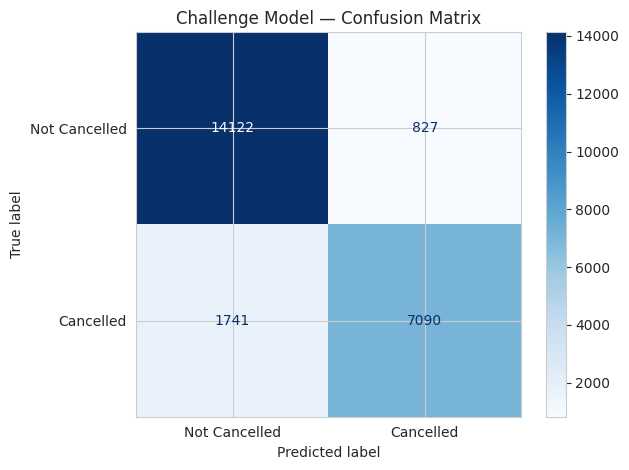

               precision    recall  f1-score   support

Not Cancelled       0.89      0.94      0.92     14949
    Cancelled       0.90      0.80      0.85      8831

     accuracy                           0.89     23780
    macro avg       0.89      0.87      0.88     23780
 weighted avg       0.89      0.89      0.89     23780



In [ ]:
# Challenge 3
from sklearn.ensemble import RandomForestClassifier

# Set up a pipeline to preprocess the data and train a random forest classifier
challenge_pipeline = Pipeline(steps=[
    ('prep',  preprocessor_m3),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs = -1))
])
challenge_pipeline.fit(X_train, y_train)

y_pred_chal = challenge_pipeline.predict(X_test)

cm_chal = confusion_matrix(y_test, y_pred_chal)
disp_chal = ConfusionMatrixDisplay(confusion_matrix=cm_chal, display_labels=['Not Cancelled', 'Cancelled'])
disp_chal.plot(cmap='Blues')
plt.title("Challenge Model — Confusion Matrix")
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_chal, target_names=['Not Cancelled', 'Cancelled']))

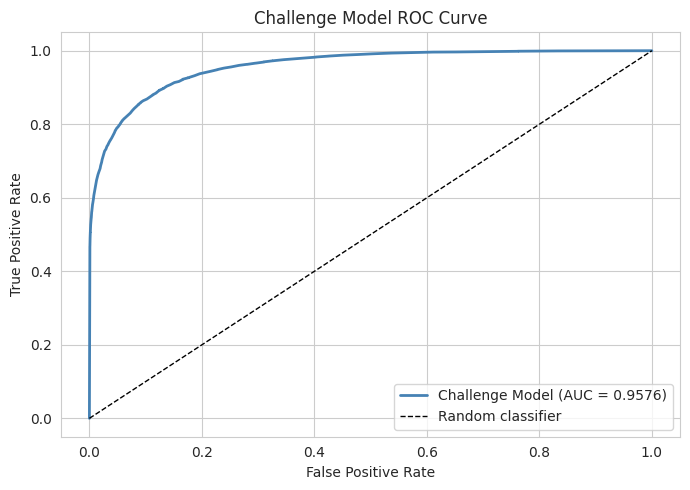

Challenge Model ROC-AUC: 0.9576


In [41]:
y_proba_chal = challenge_pipeline.predict_proba(X_test)[:, 1]
fpr_chal, tpr_chal, thresholds_chal = roc_curve(y_test, y_proba_chal)
auc_chal = roc_auc_score(y_test, y_proba_chal)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_chal, tpr_chal, lw=2, color='steelblue', label=f'Challenge Model (AUC = {auc_chal:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Challenge Model ROC Curve')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"Challenge Model ROC-AUC: {auc_chal:.4f}")

In [42]:
# AUC does improve by a significant amount.

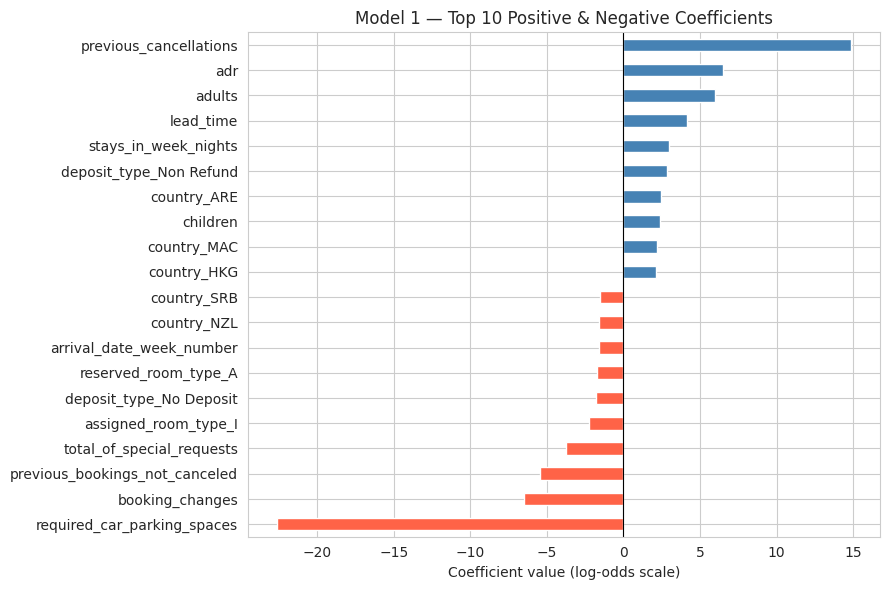

In [ ]:
# Gets one hot encoded feature names for the categorical features 
ohe_features = pipe_m1.named_steps['prep'].transformers_[0][1].get_feature_names_out(cat_features)

# Combines the categorical features with numerical features 
feature_names_m1 = list(ohe_features) + num_features

# Gets the coefficients from the logistic regression model and creates a Series with feature names as index
# Helps with identifying which features have the strongest postiive or negative influence
coefs_m1 = pd.Series(
    pipe_m1.named_steps['model'].coef_[0],
    index=feature_names_m1
).sort_values()

# Show top 10 positive and top 10 negative
top_coefs = pd.concat([coefs_m1.head(10), coefs_m1.tail(10)])

# Plot the coefficients 
top_coefs.plot(kind='barh', figsize=(9, 6), color=top_coefs.map(lambda v: 'steelblue' if v >= 0 else 'tomato'))
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Model 1 — Top 10 Positive & Negative Coefficients')
plt.xlabel('Coefficient value (log-odds scale)')
plt.tight_layout()
plt.show()

In [ ]:
# Features with large positive coefficients are strong predictors of cancellations.
# These would be previous_cancellations, adr, adults, lead_time, stay_in_week_nights, deposit_type (non-refund), coumtry (ARE, MAC, and HKG), and children.
# Features with large negative coefficients are strong predictors of non-cancellations.
# These would be country (SRB, NZL), arrival_date_week_number, reserved_room_type (A, I), deposit_type (no deposit), total_abs_special_requests, 
# previous_bookings_not_canceled, booking_changes, and required_car_parking_spaces.

# Since the numerical features were standardized using MinMaxScaler, the magnitude of the coefficients can be compared (larger absolute value means stronger influence).